<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_11_Pandas Explode.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data_jobs.csv:   0%|          | 0.00/231M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/785741 [00:00<?, ? examples/s]

## 🟨 Bar Plot of Top Skills for Cloud Engineers (2.11.1)

In [8]:
df_exploded = df.explode('job_skills')

In [11]:
skill_count = df_exploded.groupby(['job_title_short','job_skills']).size()
skill_count


job_title_short    job_skills
Business Analyst   airflow        318
                   airtable        17
                   alteryx       1078
                   angular         87
                   ansible        120
                                 ... 
Software Engineer  wrike            4
                   wsl             13
                   xamarin         35
                   yarn           145
                   zoom           229
Length: 2256, dtype: int64

In [12]:
df_skill_count = skill_count.reset_index(name='skill_count')
df_skill_count = df_skill_count.sort_values(by='skill_count',ascending =False)
df_skill_count

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


<Axes: ylabel='job_skills'>

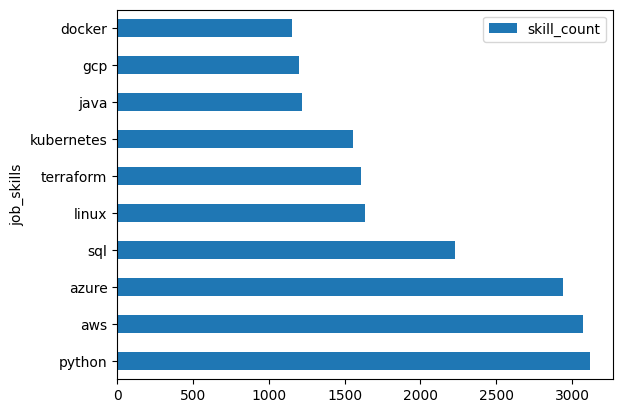

In [13]:
job_title = 'Cloud Engineer'
top_skills = 10

df_skill_final = df_skill_count[df_skill_count['job_title_short'] == job_title].head(top_skills)

df_skill_final.plot(kind='barh',x='job_skills',y='skill_count')

---

## 🟨 Average Salary by Skill (2.11.2)

In [14]:
df_exploded = df.explode('job_skills')

In [41]:
salary_by_skills = df_exploded.groupby('job_skills')['salary_year_avg'].mean()
salary_by_skills

,salary_year_avg
job_skills,
airflow,142255.967200
airtable,140615.340909
alteryx,112911.989678
angular,126330.310426
angular.js,127050.000000
...,...
wrike,101250.000000
wsl,NaN
xamarin,121250.000000


In [42]:
df_salary_by_skills = salary_by_skills.reset_index(name='salary_by_skills')
df_salary_by_skills = df_salary_by_skills.sort_values(by='salary_by_skills',ascending =False)
df_salary_by_skills.head(10)

,job_skills,salary_by_skills
46,debian,196500.000000
177,ringcentral,182500.000000
114,lua,170500.000000
126,mongo,169526.929749
54,dplyr,160667.210526
240,watson,157102.290323
136,node,156697.295455
89,haskell,155757.666667
10,asp.net core,155000.000000
198,solidity,153639.950000


<Axes: ylabel='job_skills'>

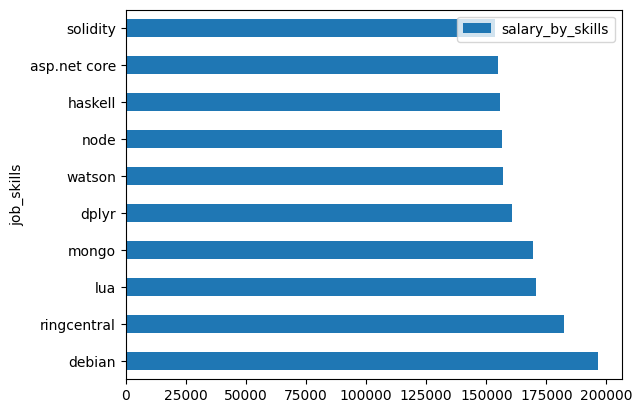

In [43]:
df_salary_by_skills.head(10).plot(kind='barh',x='job_skills',y='salary_by_skills')

---

## 🟥 Unique Skills Count (2.11.3)

In [53]:
unique_skills_count = df_exploded['job_skills'].nunique()

print(f"Number of unique skills: {unique_skills_count}")


Number of unique skills: 252


---